In [1]:
# =============================================================================
# SARIMAX: Variable Selection Scenario
# Dataset  : statsmodels Macrodata (US quarterly macroeconomic data)
# Target   : realgdp
# Scenario : Start with all candidate X variables → stepwise rejection
#            → final model with selected variables
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from itertools import product
import scipy.stats as stats



In [3]:
# =============================================================================
# 1. DATA LOADING & PREPARATION
# =============================================================================
print("=" * 65)
print("1. DATA LOADING & PREPARATION")
print("=" * 65)

macro = sm.datasets.macrodata.load_pandas().data

macro.head()



1. DATA LOADING & PREPARATION


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [8]:
quarters = pd.period_range(start='1959Q1', periods=len(macro), freq='Q')
macro.index = quarters.to_timestamp()
macro.index.freq = 'QS'
macro.index

DatetimeIndex(['1959-01-01', '1959-04-01', '1959-07-01', '1959-10-01',
               '1960-01-01', '1960-04-01', '1960-07-01', '1960-10-01',
               '1961-01-01', '1961-04-01',
               ...
               '2007-04-01', '2007-07-01', '2007-10-01', '2008-01-01',
               '2008-04-01', '2008-07-01', '2008-10-01', '2009-01-01',
               '2009-04-01', '2009-07-01'],
              dtype='datetime64[ns]', length=203, freq='QS-JAN')

In [9]:
target = macro['realgdp']

# All candidate exogenous variables (excluding year, quarter, realgdp)
all_candidates = ['realcons', 'realinv', 'realgovt', 'realdpi',
                  'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']

print(f"Date range     : {macro.index[0].date()} ~ {macro.index[-1].date()}")
print(f"Observations   : {len(macro)}")
print(f"Target (Y)     : realgdp")
print(f"Candidates (X) : {all_candidates}")



Date range     : 1959-01-01 ~ 2009-07-01
Observations   : 203
Target (Y)     : realgdp
Candidates (X) : ['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']


In [10]:
# =============================================================================
# 2. CANDIDATE VARIABLE OVERVIEW
# =============================================================================
print("\n" + "=" * 65)
print("2. CANDIDATE VARIABLE OVERVIEW")
print("=" * 65)

desc = macro[all_candidates + ['realgdp']].describe().T[['mean','std','min','max']]
print(desc.round(2).to_string())




2. CANDIDATE VARIABLE OVERVIEW
             mean      std      min       max
realcons  4825.29  2313.35  1707.40   9363.60
realinv   1012.86   585.10   259.76   2264.72
realgovt   663.33   140.86   460.40   1044.09
realdpi   5310.54  2423.52  1886.90  10077.50
cpi        105.08    61.28    28.98    218.61
m1         667.93   455.35   139.60   1673.90
tbilrate     5.31     2.80     0.12     15.33
unemp        5.88     1.46     3.40     10.70
pop        239.72    37.39   177.15    308.01
infl         3.96     3.25    -8.79     14.62
realint      1.34     2.67    -6.79     10.95
realgdp   7221.17  3214.96  2710.35  13415.27



3. CORRELATION WITH TARGET (realgdp)

  Variable       Correlation   Verdict
  ---------------------------------------------
  realcons         0.9992     Strong ✓
  realdpi          0.9990     Strong ✓
  pop              0.9933     Strong ✓
  cpi              0.9865     Strong ✓
  m1               0.9787     Strong ✓
  realinv          0.9777     Strong ✓
  realgovt         0.8687     Strong ✓
  realint         -0.0485     Weak ✗
  unemp           -0.0643     Weak ✗
  infl            -0.1919     Weak ✗
  tbilrate        -0.2757     Weak ✗


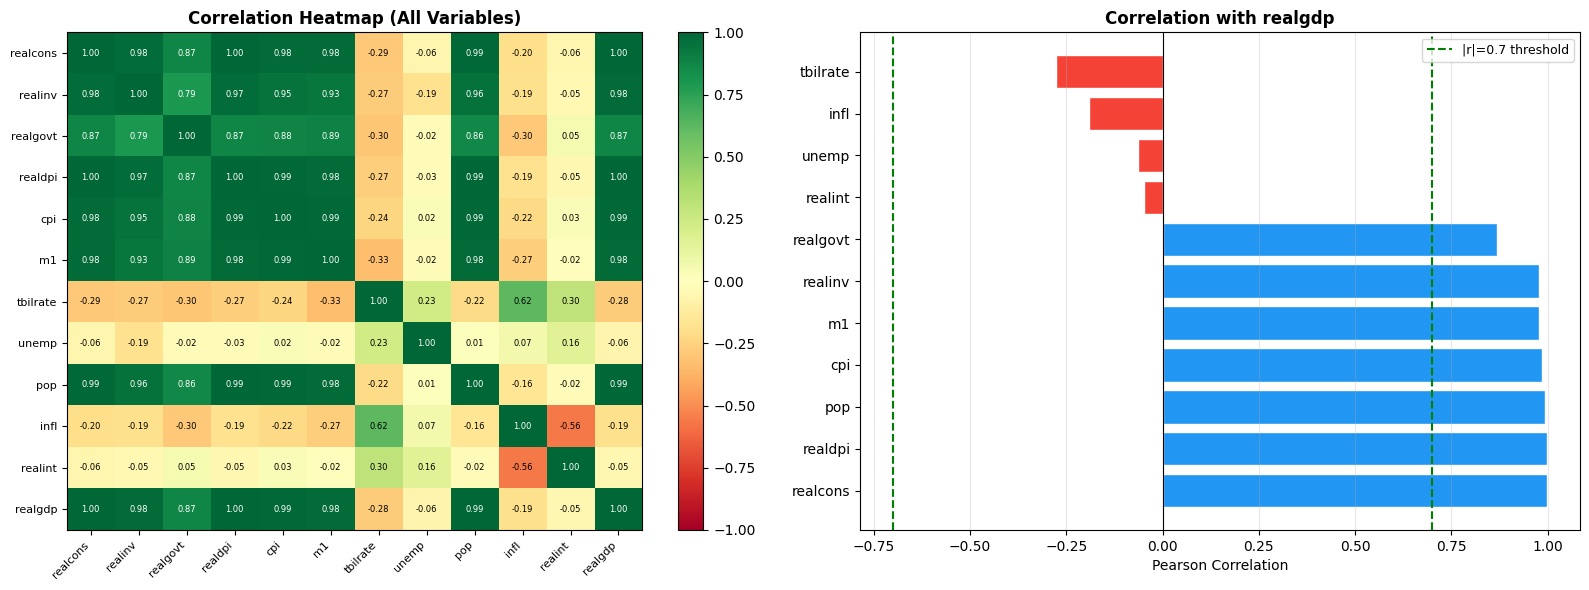

  Saved: 01_correlation.png


In [ ]:
# =============================================================================
# 3. CORRELATION WITH TARGET
# =============================================================================
print("\n" + "=" * 65)
print("3. CORRELATION WITH TARGET (realgdp)")
print("=" * 65)

corr_with_target = macro[all_candidates].corrwith(target).sort_values(ascending=False)
print("\n  Variable       Correlation   Verdict")
print("  " + "-" * 45)
for var, corr in corr_with_target.items():
    verdict = "Strong ✓" if abs(corr) > 0.7 else ("Moderate" if abs(corr) > 0.4 else "Weak ✗")
    print(f"  {var:<14} {corr:>8.4f}     {verdict}")

# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = macro[all_candidates + ['realgdp']].corr()
im = axes[0].imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(corr_matrix.columns)))
axes[0].set_yticks(range(len(corr_matrix.columns)))
axes[0].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(corr_matrix.columns, fontsize=8)
axes[0].set_title('Correlation Heatmap (All Variables)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[0])
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        axes[0].text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=6,
                     color='black' if abs(corr_matrix.values[i,j]) < 0.7 else 'white')

# Correlation with target bar
colors = ['#2196F3' if c > 0 else '#F44336' for c in corr_with_target.values]
axes[1].barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.7, color='green', linewidth=1.5, linestyle='--', label='|r|=0.7 threshold')
axes[1].axvline(-0.7, color='green', linewidth=1.5, linestyle='--')
axes[1].set_title('Correlation with realgdp', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



In [12]:
# =============================================================================
# 4. REJECTION STEP 1 — LOW CORRELATION
# =============================================================================
print("\n" + "=" * 65)
print("4. REJECTION STEP 1 — Low Correlation with Target (|r| < 0.4)")
print("=" * 65)

threshold_corr = 0.4
rejected_corr = corr_with_target[abs(corr_with_target) < threshold_corr].index.tolist()
after_corr    = [v for v in all_candidates if v not in rejected_corr]

print(f"\n  Rejected (|r| < {threshold_corr}): {rejected_corr}")
print(f"  Remaining              : {after_corr}")




4. REJECTION STEP 1 — Low Correlation with Target (|r| < 0.4)

  Rejected (|r| < 0.4): ['realint', 'unemp', 'infl', 'tbilrate']
  Remaining              : ['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'pop']



5. REJECTION STEP 2 — Multicollinearity (VIF > 10)

  VIF Results:
  Variable       VIF        Verdict
  ----------------------------------------
  realdpi         6911.15   REJECT (multicollinear) ✗
  realcons        6831.39   REJECT (multicollinear) ✗
  cpi              386.69   REJECT (multicollinear) ✗
  m1               195.43   REJECT (multicollinear) ✗
  pop              179.84   REJECT (multicollinear) ✗
  realinv          165.50   REJECT (multicollinear) ✗
  realgovt         129.63   REJECT (multicollinear) ✗

  Iterative VIF removal:
  Iter 1: Remove 'realdpi' (VIF=6911.15)
  Iter 2: Remove 'realcons' (VIF=557.89)
  Iter 3: Remove 'cpi' (VIF=238.40)
  Iter 4: Remove 'pop' (VIF=113.11)
  Iter 5: Remove 'realinv' (VIF=29.03)
  Iter 6: All VIF <= 10. Stop.

  After VIF filtering: ['realgovt', 'm1']


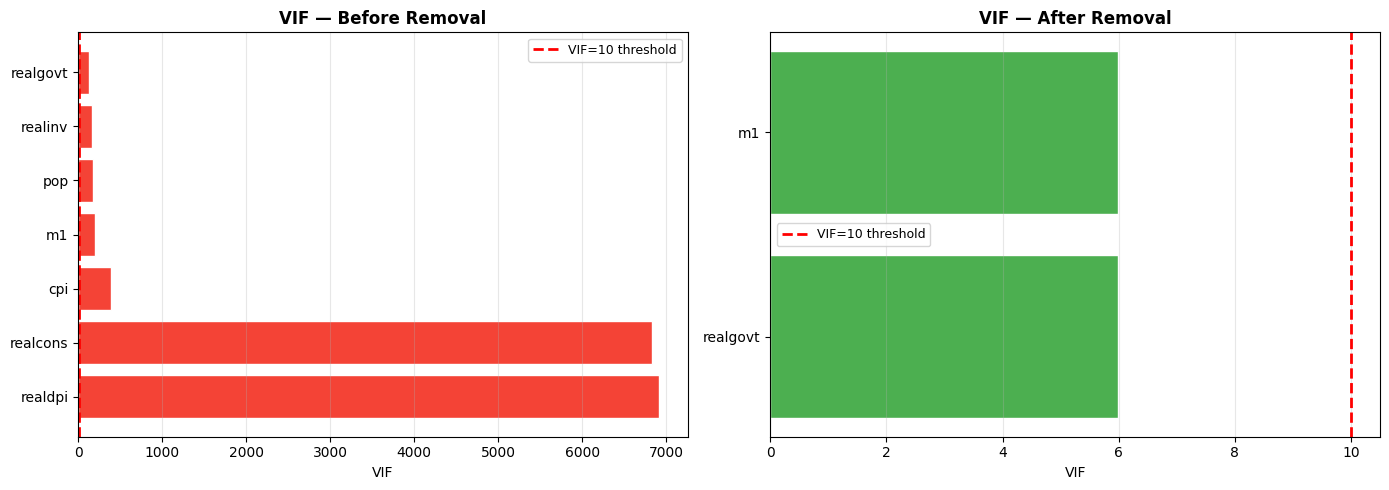

In [13]:
# =============================================================================
# 5. REJECTION STEP 2 — MULTICOLLINEARITY (VIF)
# =============================================================================
print("\n" + "=" * 65)
print("5. REJECTION STEP 2 — Multicollinearity (VIF > 10)")
print("=" * 65)

def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data['Variable'] = df.columns
    vif_data['VIF']      = [variance_inflation_factor(df.values, i)
                             for i in range(df.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

X_after_corr = macro[after_corr].dropna()
vif_df = compute_vif(X_after_corr)

print("\n  VIF Results:")
print("  Variable       VIF        Verdict")
print("  " + "-" * 40)
rejected_vif = []
for _, row in vif_df.iterrows():
    verdict = "REJECT (multicollinear) ✗" if row['VIF'] > 10 else "Keep ✓"
    print(f"  {row['Variable']:<14} {row['VIF']:>8.2f}   {verdict}")
    if row['VIF'] > 10:
        rejected_vif.append(row['Variable'])

# Iterative VIF removal (remove highest VIF one at a time)
remaining = after_corr.copy()
print("\n  Iterative VIF removal:")
iteration = 1
while True:
    X_tmp  = macro[remaining].dropna()
    vif_tmp = compute_vif(X_tmp)
    max_vif = vif_tmp['VIF'].max()
    max_var = vif_tmp.loc[vif_tmp['VIF'].idxmax(), 'Variable']
    if max_vif > 10:
        print(f"  Iter {iteration}: Remove '{max_var}' (VIF={max_vif:.2f})")
        remaining.remove(max_var)
        iteration += 1
    else:
        print(f"  Iter {iteration}: All VIF <= 10. Stop.")
        break

after_vif = remaining
print(f"\n  After VIF filtering: {after_vif}")

# VIF bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vif_df_plot = compute_vif(macro[after_corr].dropna())
colors_vif = ['#F44336' if v > 10 else '#4CAF50' for v in vif_df_plot['VIF']]
axes[0].barh(vif_df_plot['Variable'], vif_df_plot['VIF'], color=colors_vif, edgecolor='white')
axes[0].axvline(10, color='red', linewidth=2, linestyle='--', label='VIF=10 threshold')
axes[0].set_title('VIF — Before Removal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('VIF', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

vif_df_after = compute_vif(macro[after_vif].dropna())
colors_after = ['#4CAF50' for _ in vif_df_after['VIF']]
axes[1].barh(vif_df_after['Variable'], vif_df_after['VIF'], color=colors_after, edgecolor='white')
axes[1].axvline(10, color='red', linewidth=2, linestyle='--', label='VIF=10 threshold')
axes[1].set_title('VIF — After Removal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('VIF', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# 6. REJECTION STEP 3 — STATIONARITY (ADF Test on X variables)
# =============================================================================
print("\n" + "=" * 65)
print("6. REJECTION STEP 3 — ADF Test on X Variables (level)")
print("=" * 65)

print("\n  Variable       ADF Stat    p-value    Stationary?   Action")
print("  " + "-" * 62)

rejected_adf = []
after_adf    = []
for var in after_vif:
    result = adfuller(macro[var].dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    is_stat = pval < 0.05
    # Check if 1st difference is stationary
    diff_result = adfuller(macro[var].diff().dropna(), autolag='AIC')
    diff_stat   = diff_result[1] < 0.05
    if is_stat:
        action = "Use level ✓"
        after_adf.append(var)
    elif diff_stat:
        action = "Use d=1 ✓"
        after_adf.append(var)
    else:
        action = "REJECT ✗"
        rejected_adf.append(var)
    print(f"  {var:<14} {stat:>8.4f}  {pval:>8.4f}   {'Yes' if is_stat else 'No':<12}  {action}")

print(f"\n  After ADF check : {after_adf}")
if rejected_adf:
    print(f"  Rejected        : {rejected_adf}")

# Final selected variables
final_vars = after_adf
print(f"\n  >>> Final selected X variables: {final_vars}")




6. REJECTION STEP 3 — ADF Test on X Variables (level)

  Variable       ADF Stat    p-value    Stationary?   Action
  --------------------------------------------------------------
  realgovt        -0.0316    0.9558   No            Use d=1 ✓
  m1               2.0531    0.9987   No            Use d=1 ✓

  After ADF check : ['realgovt', 'm1']

  >>> Final selected X variables: ['realgovt', 'm1']



7. VARIABLE SELECTION SUMMARY
Variable   Corr Step1(Corr) Step2(VIF) Step3(ADF)      Final
realcons  0.999        Pass     REJECT          — Rejected ✗
 realinv  0.978        Pass     REJECT          — Rejected ✗
realgovt  0.869        Pass       Pass       Pass SELECTED ✓
 realdpi  0.999        Pass     REJECT          — Rejected ✗
     cpi  0.987        Pass     REJECT          — Rejected ✗
      m1  0.979        Pass       Pass       Pass SELECTED ✓
tbilrate -0.276      REJECT          —          — Rejected ✗
   unemp -0.064      REJECT          —          — Rejected ✗
     pop  0.993        Pass     REJECT          — Rejected ✗
    infl -0.192      REJECT          —          — Rejected ✗
 realint -0.048      REJECT          —          — Rejected ✗


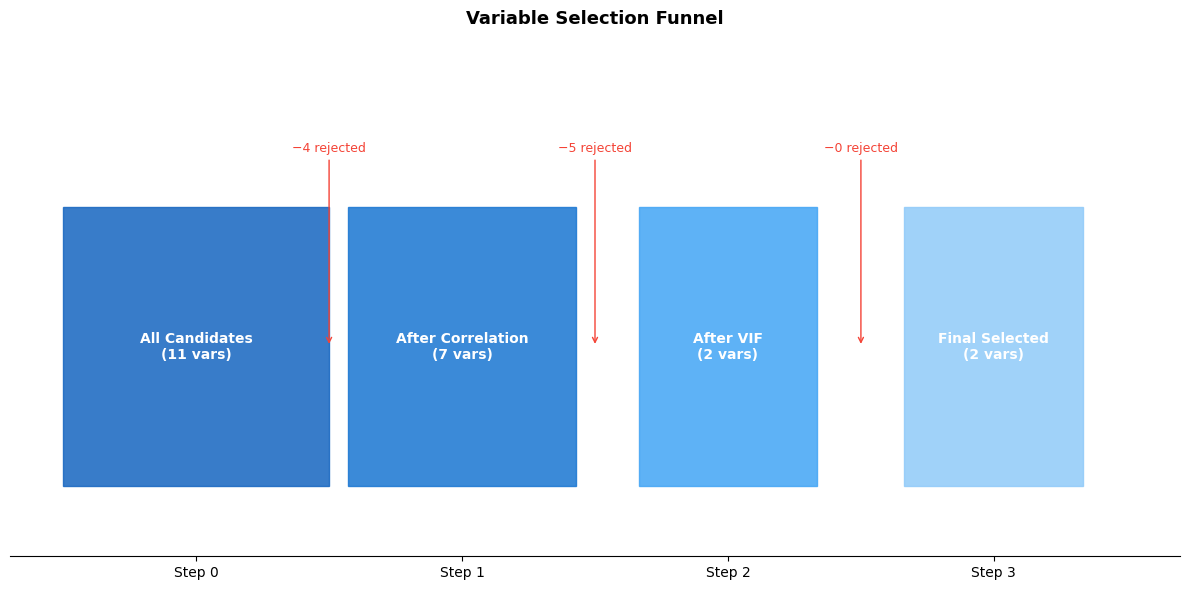

  Saved: 03_selection_funnel.png


In [ ]:
# =============================================================================
# 7. VARIABLE SELECTION SUMMARY
# =============================================================================
print("\n" + "=" * 65)
print("7. VARIABLE SELECTION SUMMARY")
print("=" * 65)

all_vars_info = []
for var in all_candidates:
    corr_val = corr_with_target[var]
    step1 = "REJECT" if var in rejected_corr else "Pass"
    step2 = "REJECT" if var not in after_vif and var not in rejected_corr else ("Pass" if var in after_vif else "—")
    step3 = "REJECT" if var in rejected_adf else ("Pass" if var in final_vars else "—")
    final = "SELECTED ✓" if var in final_vars else "Rejected ✗"
    all_vars_info.append({
        'Variable': var,
        'Corr': f'{corr_val:.3f}',
        'Step1(Corr)': step1,
        'Step2(VIF)': step2,
        'Step3(ADF)': step3,
        'Final': final
    })

summary_df = pd.DataFrame(all_vars_info)
print(summary_df.to_string(index=False))

# Funnel visualization
fig, ax = plt.subplots(figsize=(12, 6))

stages = [
    f'All Candidates\n({len(all_candidates)} vars)',
    f'After Correlation\n({len(after_corr)} vars)',
    f'After VIF\n({len(after_vif)} vars)',
    f'Final Selected\n({len(final_vars)} vars)'
]
counts = [len(all_candidates), len(after_corr), len(after_vif), len(final_vars)]
colors_funnel = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']

for i, (stage, count, color) in enumerate(zip(stages, counts, colors_funnel)):
    width = 0.6 + (count / len(all_candidates)) * 0.4
    rect = plt.Rectangle((i - width/2, 0), width, 0.8,
                          color=color, alpha=0.85, zorder=3)
    ax.add_patch(rect)
    ax.text(i, 0.4, stage, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', zorder=4)
    if i < len(stages) - 1:
        rejected_n = counts[i] - counts[i+1]
        ax.annotate(f'−{rejected_n} rejected',
                    xy=(i + 0.5, 0.4), fontsize=9, color='#F44336',
                    ha='center', va='bottom',
                    xytext=(i + 0.5, 0.95),
                    arrowprops=dict(arrowstyle='->', color='#F44336'))

ax.set_xlim(-0.7, len(stages) - 0.3)
ax.set_ylim(-0.2, 1.3)
ax.set_xticks(range(len(stages)))
ax.set_xticklabels([f'Step {i}' for i in range(len(stages))], fontsize=10)
ax.set_yticks([])
ax.set_title('Variable Selection Funnel', fontsize=13, fontweight='bold')
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()



In [16]:
# =============================================================================
# 8. TRAIN / TEST SPLIT
# =============================================================================
print("\n" + "=" * 65)
print("8. TRAIN / TEST SPLIT")
print("=" * 65)

n_test  = 12
exog    = macro[final_vars]
train_y = target.iloc[:-n_test]
test_y  = target.iloc[-n_test:]
train_X = exog.iloc[:-n_test]
test_X  = exog.iloc[-n_test:]

print(f"  Train: {train_y.index[0].date()} ~ {train_y.index[-1].date()}  ({len(train_y)} obs)")
print(f"  Test : {test_y.index[0].date()} ~ {test_y.index[-1].date()}   ({len(test_y)} obs)")
print(f"  Final exog variables: {final_vars}")




8. TRAIN / TEST SPLIT
  Train: 1959-01-01 ~ 2006-07-01  (191 obs)
  Test : 2006-10-01 ~ 2009-07-01   (12 obs)
  Final exog variables: ['realgovt', 'm1']


In [17]:
# =============================================================================
# 9. GRID SEARCH — Best (p,d,q)(P,D,Q,s)
# =============================================================================
print("\n" + "=" * 65)
print("9. GRID SEARCH (AIC-based)")
print("=" * 65)

p_range = range(0, 3)
d_range = [1]
q_range = range(0, 3)
P_range = range(0, 2)
D_range = [0, 1]
Q_range = range(0, 2)
s       = 4

best_aic    = np.inf
best_order  = None
best_sorder = None
results_grid = []

combos = list(product(p_range, d_range, q_range, P_range, D_range, Q_range))
print(f"  Testing {len(combos)} combinations...", end='', flush=True)

for p, d, q, P, D, Q in combos:
    try:
        model = SARIMAX(
            train_y, exog=train_X,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)
        results_grid.append({
            'order': (p, d, q), 'seasonal_order': (P, D, Q, s),
            'aic': res.aic, 'bic': res.bic
        })
        if res.aic < best_aic:
            best_aic    = res.aic
            best_order  = (p, d, q)
            best_sorder = (P, D, Q, s)
    except Exception:
        pass

print(" Done.")
print(f"\n  Best order          : ARIMA{best_order}")
print(f"  Best seasonal order : SARIMA{best_sorder}")
print(f"  Best AIC            : {best_aic:.2f}")
print(f"\n  Top 5 by AIC:")
print(pd.DataFrame(results_grid).sort_values('aic').head(5).to_string(index=False))




9. GRID SEARCH (AIC-based)
  Testing 72 combinations...

/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

 Done.

  Best order          : ARIMA(1, 1, 2)
  Best seasonal order : SARIMA(0, 1, 1, 4)
  Best AIC            : 1923.93

  Top 5 by AIC:
    order seasonal_order         aic         bic
(1, 1, 2)   (0, 1, 1, 4) 1923.927429 1946.239129
(0, 1, 2)   (0, 1, 1, 4) 1924.713276 1943.837591
(1, 1, 2)   (1, 1, 1, 4) 1924.958454 1950.457540
(2, 1, 2)   (0, 1, 1, 4) 1925.473245 1950.972332
(0, 1, 2)   (1, 1, 1, 4) 1925.912883 1948.224584


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
# =============================================================================
# 10. FINAL MODEL FITTING
# =============================================================================
print("\n" + "=" * 65)
print("10. FINAL MODEL FITTING")
print("=" * 65)

final_model = SARIMAX(
    train_y, exog=train_X,
    order=best_order,
    seasonal_order=best_sorder,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit(disp=False)
print(final_result.summary())




10. FINAL MODEL FITTING
                                      SARIMAX Results                                      
Dep. Variable:                             realgdp   No. Observations:                  191
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 4)   Log Likelihood                -954.964
Date:                             Wed, 22 Apr 2026   AIC                           1923.927
Time:                                     17:13:28   BIC                           1946.239
Sample:                                 01-01-1959   HQIC                          1932.975
                                      - 07-01-2006                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realgovt       0.8702      0.275      3.159      0.002       0.330       1.410
m1


11. EXOGENOUS VARIABLE SIGNIFICANCE (p-value)

  Variable       Coef        Std Err    p-value    Significant?
  ------------------------------------------------------------
  realgovt           0.8702     0.2754     0.0016   Yes **
  m1                -0.5993     0.5119     0.2417   No  n.s.


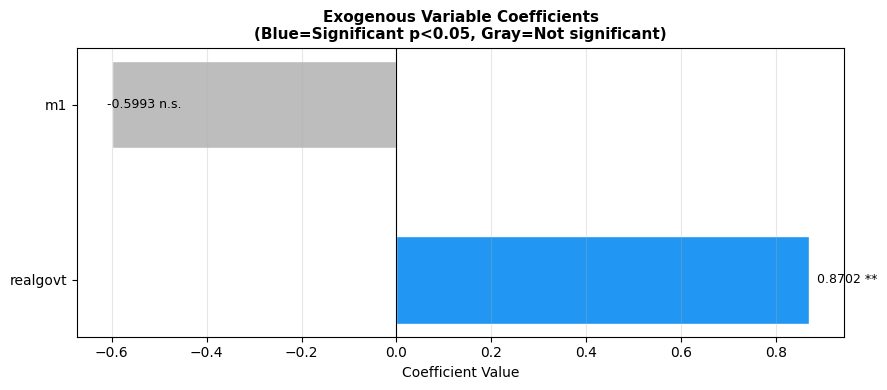

In [19]:
# =============================================================================
# 11. EXOGENOUS VARIABLE SIGNIFICANCE (p-value check)
# =============================================================================
print("\n" + "=" * 65)
print("11. EXOGENOUS VARIABLE SIGNIFICANCE (p-value)")
print("=" * 65)

print(f"\n  Variable       Coef        Std Err    p-value    Significant?")
print("  " + "-" * 60)
coef_rows = []
for var in final_vars:
    if var in final_result.params.index:
        coef  = final_result.params[var]
        se    = final_result.bse[var]
        pval  = final_result.pvalues[var]
        sig   = pval < 0.05
        stars = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'n.s.'))
        print(f"  {var:<14} {coef:>10.4f}  {se:>9.4f}  {pval:>9.4f}   {'Yes '+stars if sig else 'No  '+stars}")
        coef_rows.append({'var': var, 'coef': coef, 'pval': pval, 'sig': sig, 'stars': stars})

# Coefficient plot
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_rows)*0.7 + 1)))
vars_   = [r['var'] for r in coef_rows]
coefs_  = [r['coef'] for r in coef_rows]
pvals_  = [r['pval'] for r in coef_rows]
colors_ = ['#2196F3' if r['sig'] else '#BDBDBD' for r in coef_rows]

bars = ax.barh(vars_, coefs_, color=colors_, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Exogenous Variable Coefficients\n(Blue=Significant p<0.05, Gray=Not significant)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Value', fontsize=10)
for bar, row in zip(bars, coef_rows):
    x_pos = row['coef'] + (max(coefs_) * 0.02 if row['coef'] >= 0 else min(coefs_) * 0.02)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{row['coef']:.4f} {row['stars']}",
            va='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()




12. RESIDUAL DIAGNOSTICS
  Ljung-Box p-value (lag=10): 0.0000  ✗ Autocorrelation remains


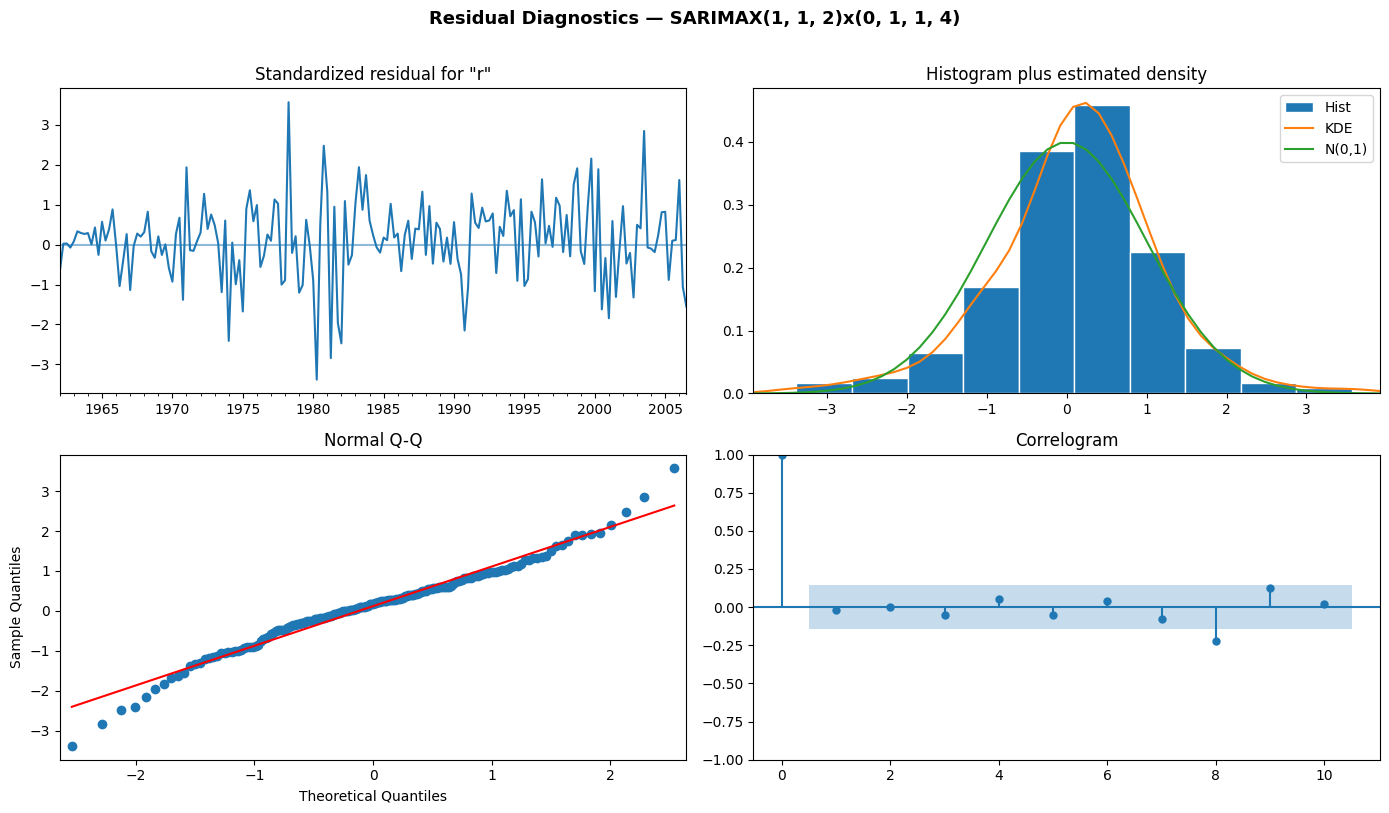

In [20]:
# =============================================================================
# 12. RESIDUAL DIAGNOSTICS
# =============================================================================
print("\n" + "=" * 65)
print("12. RESIDUAL DIAGNOSTICS")
print("=" * 65)

residuals = final_result.resid
lb_test   = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"  Ljung-Box p-value (lag=10): {lb_test['lb_pvalue'].values[0]:.4f}  "
      f"{'✓ White noise' if lb_test['lb_pvalue'].values[0] > 0.05 else '✗ Autocorrelation remains'}")

fig = final_result.plot_diagnostics(figsize=(14, 8))
fig.suptitle(f'Residual Diagnostics — SARIMAX{best_order}x{best_sorder}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# =============================================================================
# 13. FORECAST & EVALUATION
# =============================================================================
print("\n" + "=" * 65)
print("13. FORECAST & EVALUATION")
print("=" * 65)

forecast      = final_result.get_forecast(steps=n_test, exog=test_X)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int(alpha=0.05)

mae  = np.mean(np.abs(forecast_mean - test_y))
rmse = np.sqrt(np.mean((forecast_mean - test_y)**2))
mape = np.mean(np.abs((forecast_mean - test_y) / test_y)) * 100

print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAPE : {mape:.2f}%")

forecast_df = pd.DataFrame({
    'Actual'   : test_y.values,
    'Forecast' : forecast_mean.values,
    'Lower_95' : forecast_ci.iloc[:, 0].values,
    'Upper_95' : forecast_ci.iloc[:, 1].values,
    'Error'    : forecast_mean.values - test_y.values
}, index=test_y.index)
print(f"\n  Forecast vs Actual:")
print(forecast_df.round(2).to_string())


13. FORECAST & EVALUATION
  MAE  : 251.25
  RMSE : 370.31
  MAPE : 1.93%

  Forecast vs Actual:
              Actual  Forecast  Lower_95  Upper_95   Error
2006-10-01  13060.68  13020.57  12923.57  13117.58  -40.10
2007-01-01  13099.90  13054.43  12898.26  13210.59  -45.47
2007-04-01  13203.98  13136.36  12920.80  13351.93  -67.61
2007-07-01  13321.11  13209.31  12939.19  13479.44 -111.79
2007-10-01  13391.25  13287.76  12964.54  13610.98 -103.49
2008-01-01  13366.86  13365.66  12993.99  13737.33   -1.20
2008-04-01  13415.27  13438.25  13021.91  13854.60   22.99
2008-07-01  13324.60  13491.60  13034.00  13949.20  167.00
2008-10-01  13141.92  13519.22  13020.57  14017.86  377.30
2009-01-01  12925.41  13567.43  13029.94  14104.91  642.02
2009-04-01  12901.50  13627.72  13053.23  14202.21  726.22
2009-07-01  12990.34  13700.10  13090.44  14309.77  709.76


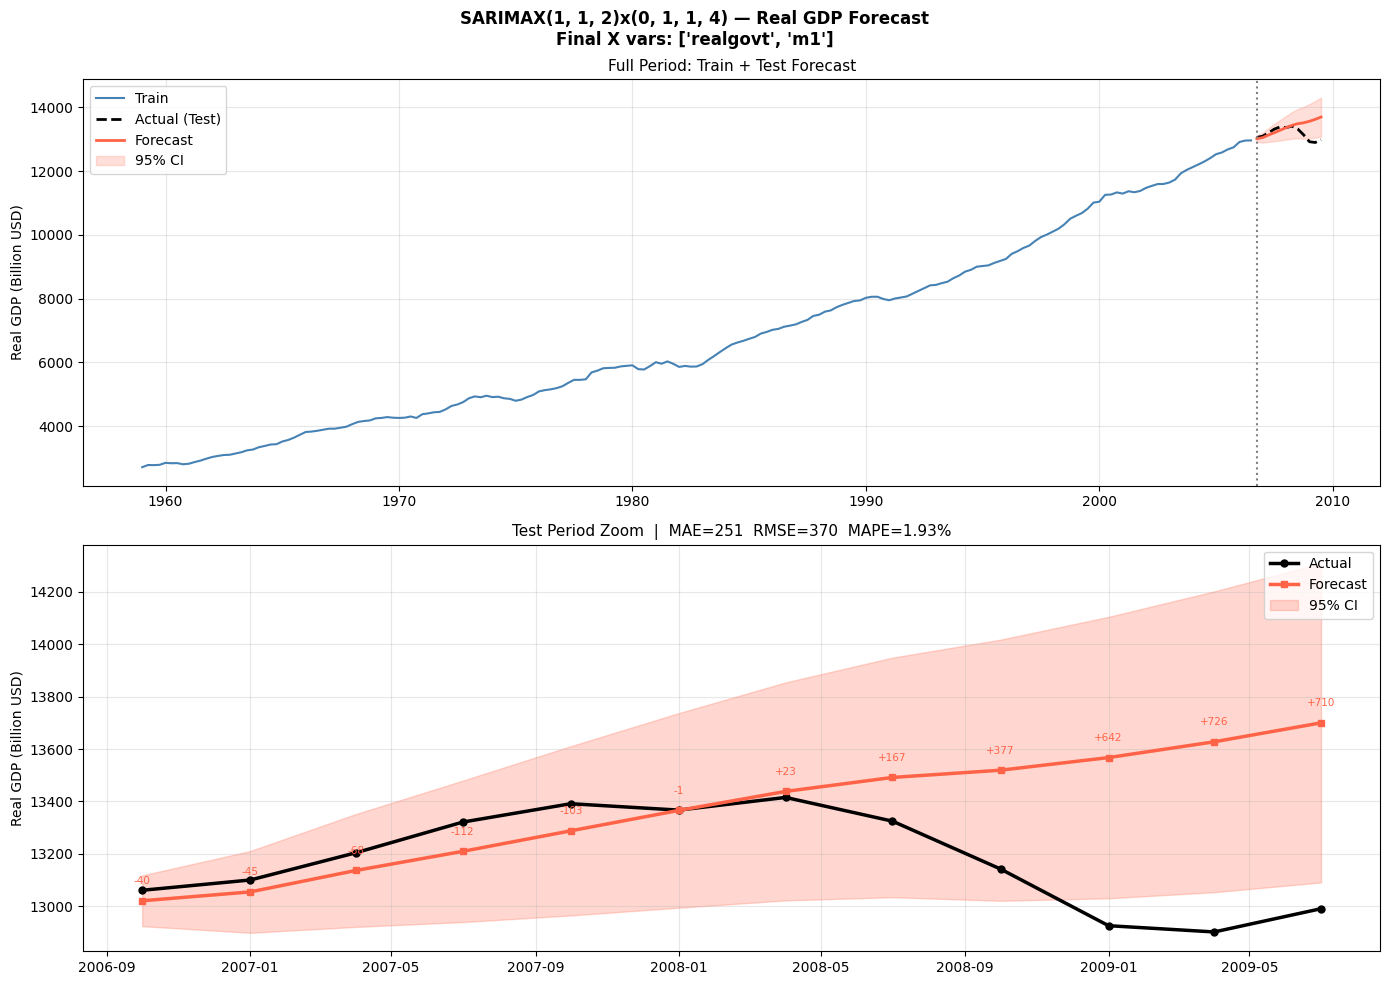

In [22]:
# =============================================================================
# 14. FORECAST VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'SARIMAX{best_order}x{best_sorder} — Real GDP Forecast\n'
             f'Final X vars: {final_vars}',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(train_y.index, train_y, label='Train', color='steelblue', linewidth=1.5)
ax.plot(test_y.index, test_y, label='Actual (Test)', color='black', linewidth=2, linestyle='--')
ax.plot(forecast_mean.index, forecast_mean, label='Forecast', color='tomato', linewidth=2)
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                alpha=0.2, color='tomato', label='95% CI')
ax.axvline(test_y.index[0], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Full Period: Train + Test Forecast', fontsize=11)
ax.set_ylabel('Real GDP (Billion USD)', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(test_y.index, test_y, label='Actual', color='black',
         linewidth=2.5, marker='o', markersize=5)
ax2.plot(forecast_mean.index, forecast_mean, label='Forecast', color='tomato',
         linewidth=2.5, marker='s', markersize=5)
ax2.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                 alpha=0.25, color='tomato', label='95% CI')
for idx, row in forecast_df.iterrows():
    ax2.annotate(f'{row["Error"]:+,.0f}',
                 xy=(idx, row['Forecast']),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=7.5, color='tomato')
ax2.set_title(f'Test Period Zoom  |  MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape:.2f}%',
              fontsize=11)
ax2.set_ylabel('Real GDP (Billion USD)', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
# 15. FINAL SUMMARY
# =============================================================================
print("\n" + "=" * 65)
print("15. FINAL SUMMARY")
print("=" * 65)
print(f"\n  [Variable Selection]")
print(f"  All candidates  : {len(all_candidates)} vars  {all_candidates}")
print(f"  After corr(|r|<{threshold_corr}): {len(after_corr)} vars  {after_corr}")
print(f"  After VIF(>10)  : {len(after_vif)} vars  {after_vif}")
print(f"  After ADF check : {len(final_vars)} vars  {final_vars}")
print(f"\n  [Model]")
print(f"  SARIMAX{best_order}x{best_sorder}")
print(f"  AIC : {best_aic:.2f}")
print(f"\n  [Forecast Performance]")
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"\n  [Exogenous Coefficients]")
for row in coef_rows:
    sig_str = 'Significant' if row['sig'] else 'Not significant'
    print(f"  {row['var']:<14}: coef={row['coef']:>10.4f}  p={row['pval']:.4f}  {sig_str} {row['stars']}")
print("\nDone.")



15. FINAL SUMMARY

  [Variable Selection]
  All candidates  : 11 vars  ['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']
  After corr(|r|<0.4): 7 vars  ['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'pop']
  After VIF(>10)  : 2 vars  ['realgovt', 'm1']
  After ADF check : 2 vars  ['realgovt', 'm1']

  [Model]
  SARIMAX(1, 1, 2)x(0, 1, 1, 4)
  AIC : 1923.93

  [Forecast Performance]
  MAE  : 251.25
  RMSE : 370.31
  MAPE : 1.93%

  [Exogenous Coefficients]
  realgovt      : coef=    0.8702  p=0.0016  Significant **
  m1            : coef=   -0.5993  p=0.2417  Not significant n.s.

Done.



16. AUTO_ARIMA -> SARIMAX (MAPE + Forecast)
  auto_arima order          : (2, 2, 2)
  auto_arima seasonal_order : (2, 0, 2, 4)
  auto_arima AIC            : 2016.72


/Users/erickim/Documents/ML_Training/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  [Auto-ARIMA SARIMAX Forecast Performance]
  MAPE : 2.27%


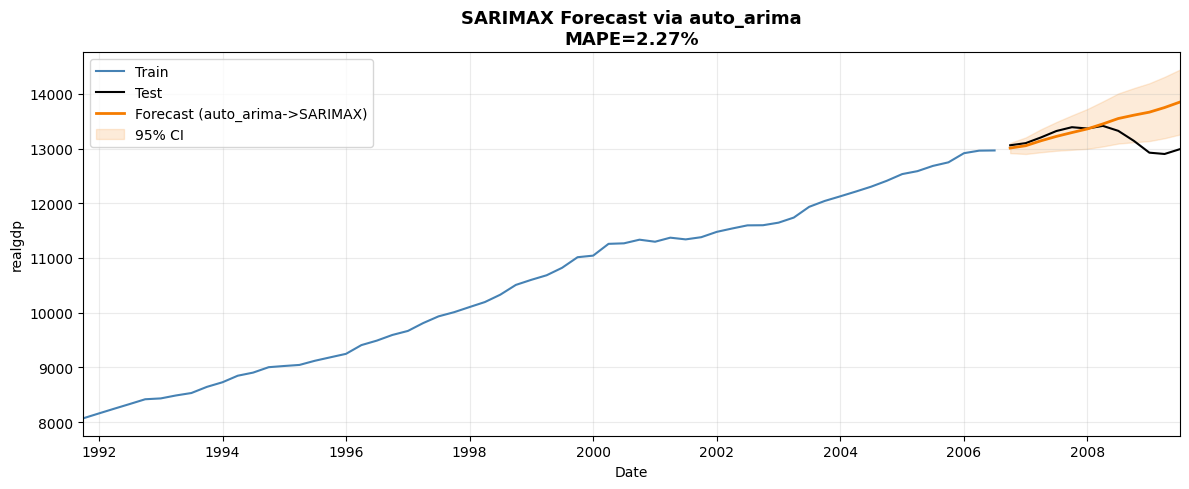

In [25]:
# =============================================================================
# 16. AUTO_ARIMA -> SARIMAX (with exogenous) + MAPE + FORECAST
# =============================================================================
print("\n" + "=" * 65)
print("16. AUTO_ARIMA -> SARIMAX (MAPE + Forecast)")
print("=" * 65)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pmdarima 설치/임포트 (환경에 없을 수 있음)
try:
    from pmdarima import auto_arima
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pmdarima"])
    from pmdarima import auto_arima

# auto_arima로 (p,d,q) 및 (P,D,Q,m) 선택 (분기 데이터 가정: m=4)
auto_model = auto_arima(
    train_y,
    exogenous=train_X,
    seasonal=True,
    m=4,
    start_p=0,
    start_q=0,
    max_p=4,
    max_q=4,
    max_d=2,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    max_D=1,
    information_criterion="aic",
    stepwise=True,
    error_action="ignore",
    suppress_warnings=True,
    trace=False,
)

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f"  auto_arima order          : {order}")
print(f"  auto_arima seasonal_order : {seasonal_order}")
print(f"  auto_arima AIC            : {auto_model.aic():.2f}")

from statsmodels.tsa.statespace.sarimax import SARIMAX

auto_sarimax = SARIMAX(
    train_y,
    exog=train_X,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

auto_result = auto_sarimax.fit(disp=False)

# 테스트 구간 예측
fcst = auto_result.get_forecast(steps=n_test, exog=test_X)
pred = fcst.predicted_mean
ci = fcst.conf_int()

# MAPE
mape_auto = float(np.mean(np.abs((test_y - pred) / test_y)) * 100)
print(f"\n  [Auto-ARIMA SARIMAX Forecast Performance]")
print(f"  MAPE : {mape_auto:.2f}%")

# 시각화 (예측구간이 잘 보이도록 최근 구간만 확대)
# - 최근 plot_window개 관측치(훈련 꼬리) + 테스트/예측 구간을 표시
plot_window = 60
plot_window = min(plot_window, len(train_y))
plot_start = train_y.index[-plot_window]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_y.loc[plot_start:].index, train_y.loc[plot_start:], label="Train", color="steelblue", linewidth=1.5)
ax.plot(test_y.index, test_y, label="Test", color="black", linewidth=1.5)
ax.plot(pred.index, pred, label="Forecast (auto_arima->SARIMAX)", color="#F57C00", linewidth=2)

# 신뢰구간
lower = ci.iloc[:, 0]
upper = ci.iloc[:, 1]
ax.fill_between(pred.index, lower, upper, color="#F57C00", alpha=0.15, label="95% CI")

# x축 범위를 최근 구간으로 제한
ax.set_xlim(plot_start, pred.index[-1])

ax.set_title(f"SARIMAX Forecast via auto_arima\nMAPE={mape_auto:.2f}%", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel(train_y.name if getattr(train_y, "name", None) else "y")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
